# 이커머스 주문 데이터의 탐색적 분석과 RFM 세분화

주문 3,999건을 한 테이블에서 다룬다. 수치·범주·날짜·상품명·이미지 배열이 함께 있고, 전처리와 RFM은 `src/pipeline.py`의 `DataAnalyzer`가 맡는다. 이 노트북은 그 클래스를 호출해 구조를 읽고, 결측과 이상치를 처리하고, 여섯 종류의 차트로 분포와 고객 세그먼트를 확인한다.

해석에 적힌 수치는 바로 위 셀의 출력과 같다. Recency 기준일은 따로 지정하지 않으며, 최종 거래일을 쓴다.


## 1. 환경

차트 제목의 한글은 AppleGothic 파일이 있을 때 그 글꼴로 그린다. macOS에서 Matplotlib가 시스템 폰트 목록을 읽다 실패하는 경우가 있어, Matplotlib를 불러오기 전에 `MPL_IGNORE_SYSTEM_FONTS`를 켠다. 분석 계산 자체는 NumPy와 Pandas만 사용한다.


In [3]:
import os
from pathlib import Path
import sys

os.environ["MPL_IGNORE_SYSTEM_FONTS"] = "1"

%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager
from matplotlib.ticker import FuncFormatter

ROOT = Path.cwd().resolve()
if not (ROOT / "src" / "pipeline.py").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.pipeline import SEGMENT_ORDER, DataAnalyzer

FONT_CANDIDATES = [
    Path("/System/Library/Fonts/Supplemental/AppleGothic.ttf"),
    Path("/Library/Fonts/Arial Unicode.ttf"),
]
FONT_PATH = next((path for path in FONT_CANDIDATES if path.exists()), None)
KFONT = font_manager.FontProperties(fname=str(FONT_PATH)) if FONT_PATH else font_manager.FontProperties()

sns.set_theme(style="whitegrid")
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")


def style_ax(ax, title, xlabel, ylabel):
    ax.set_title(title, fontproperties=KFONT, fontsize=13, pad=10)
    ax.set_xlabel(xlabel, fontproperties=KFONT, labelpad=6)
    ax.set_ylabel(ylabel, fontproperties=KFONT, labelpad=10)
    for label in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
        label.set_fontproperties(KFONT)


def style_legend(ax, title=None):
    legend = ax.get_legend()
    if legend is None:
        return
    if title is not None:
        legend.set_title(title, prop=KFONT)
    legend.get_title().set_fontproperties(KFONT)
    for text in legend.get_texts():
        text.set_fontproperties(KFONT)


print("root", ROOT)
print("font", FONT_PATH)


root /Users/qlckem6827/Codyssey/A1-1-TASK
font /System/Library/Fonts/Supplemental/AppleGothic.ttf


## 2. 데이터 로드와 구조

`load_data()`가 CSV를 읽고 `order_date`를 datetime으로 바꾼다. 이 절의 `info()`, `describe()`, `head()`는 피처를 더하기 전의 원본 13열이다.


In [5]:
analyzer = DataAnalyzer(ROOT / "data" / "ecommerce_orders.csv")
frame = analyzer.load_data()
print(f"rows={len(frame):,} cols={frame.shape[1]}")
print(f"customers={frame['customer_id'].nunique():,} products={frame['product_id'].nunique():,}")
print(f"date_range={frame['order_date'].min().date()} ~ {frame['order_date'].max().date()}")
print(f"span_days={(frame['order_date'].max() - frame['order_date'].min()).days}")
frame.info()


rows=3,999 cols=13
customers=640 products=48
date_range=2024-03-01 ~ 2025-06-30
span_days=486
<class 'pandas.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      3999 non-null   str           
 1   customer_id   3999 non-null   str           
 2   order_date    3999 non-null   datetime64[us]
 3   product_id    3999 non-null   str           
 4   product_name  3999 non-null   str           
 5   category      3999 non-null   str           
 6   quantity      3999 non-null   int64         
 7   unit_price    3999 non-null   int64         
 8   amount        3999 non-null   int64         
 9   region        3999 non-null   str           
 10  channel       3999 non-null   str           
 11  rating        3528 non-null   float64       
 12  image_flat    3999 non-null   str           
dtypes: datetime64[us](1), float64(1), int64(3), str(8)
memo

### info() 해석

주문은 3,999행, 13열이다. 고객은 640명, 상품은 48개이고 거래일은 2024-03-01부터 2025-06-30까지 486일이다. 결측은 `rating`만 471건이고 나머지 12열은 3,999건이 모두 채워져 있다. `order_date`는 datetime이고, `quantity`·`unit_price`·`amount`는 정수, `rating`은 실수다. `category`·`region`·`channel`은 범주, `product_name`은 텍스트, `image_flat`은 이미지 배열을 공백으로 이어 붙인 문자열이다.

시사점: 행 하나는 주문 1건이므로 고객 640명의 Recency·Frequency·Monetary는 이후 `customer_id`로 묶어 계산한다.


In [7]:
frame.describe()


,order_date,quantity,unit_price,amount,rating
count,3999,"3,999.0000","3,999.0000","3,999.0000","3,528.0000"
mean,2025-01-01 19:34:58.424606,2.4559,"54,415.7789","131,484.6462",4.0526
min,2024-03-01 00:00:00,1.0000,"5,300.0000","5,300.0000",2.4000
25%,2024-10-18 00:00:00,1.0000,"21,200.0000","31,000.0000",3.8000
50%,2025-01-08 00:00:00,2.0000,"38,200.0000","60,000.0000",4.1000
75%,2025-03-26 00:00:00,2.0000,"72,500.0000","120,300.0000",4.4000
max,2025-06-30 00:00:00,212.0000,"297,100.0000","15,518,100.0000",5.0000
std,NaN,8.0870,"47,237.6729","481,699.9964",0.4543


### describe() 해석

처리 전 주문 금액의 평균은 131,485원이고 중앙값은 60,000원이다. 평균이 중앙값의 2.19배이고 최댓값은 15,518,100원이다. 수량은 중앙값 2, 최댓값 212, 표준편차 8.09로 오른쪽 꼬리가 길다. 단가는 평균 54,416원, 중앙값 38,200원, 최댓값 297,100원이다. 평점은 결측을 뺀 3,528건에서 평균 4.05, 중앙값 4.1, 표준편차 0.45다.

시사점: 금액과 수량의 평균은 소수 극단값에 끌려 있으므로, 대표 주문 규모는 평균 대신 중앙값(금액 60,000원, 수량 2개)으로 읽는 편이 맞다.


In [9]:
preview = frame.head().copy()
preview["image_flat"] = preview["image_flat"].str.slice(0, 42) + " ..."
preview


,order_id,customer_id,order_date,product_id,product_name,category,quantity,unit_price,amount,region,channel,rating,image_flat
0,O001713,C0270,2024-03-01,P011,여름 린넨 셔츠,Fashion,1,38500,38500,부산,App,4.1000,0.5406 0.7039 0.6802 0.5671 0.5380 0.7058 ...
1,O003101,C0505,2024-03-08,P046,허브티 20티백,Food,2,6500,13000,인천,Store,3.4000,0.5503 0.7573 0.7603 0.6507 0.5604 0.7324 ...
2,O001953,C0310,2024-03-28,P025,수분 진정 토너,Beauty,1,13000,13000,서울,App,4.7000,0.8131 0.9133 0.9060 0.7924 0.7008 0.8862 ...
3,O000440,C0073,2024-03-29,P034,스테인리스 텀블러,Sports,2,12300,24600,인천,App,4.0000,0.3361 0.5219 0.3363 0.2985 0.5082 0.4888 ...
4,O001882,C0296,2024-03-29,P025,수분 진정 토너,Beauty,1,24200,24200,서울,App,4.6000,0.7941 0.8223 0.8470 0.8156 0.6992 0.8417 ...


### head() 해석

첫 주문 `O001713`은 2024-03-01, 고객 `C0270`, 상품 `여름 린넨 셔츠`(Fashion), 수량 1, 금액 38,500원, 지역 부산, 채널 App, 평점 4.1이다. `image_flat`은 0에서 1 사이의 소수가 이어진 16×16 배열이다.

시사점: 상품명과 이미지가 금액·날짜와 같은 행에 있으므로, 고객 단위로 묶기 전에 행 단위로 텍스트 길이와 이미지 밝기를 붙일 수 있다.


## 3. 결측치 현황

결측이 있는 열과 카테고리별 평점 결측률을 먼저 본다. 대치는 이상치 처리 뒤에 같은 전략으로 적용한다.


In [12]:
missing = analyzer.missing_summary()
display(missing)

rating_by_category = frame.groupby("category")["rating"].agg(
    observed="count",
    mean="mean",
    median="median",
)
rating_by_category = rating_by_category.join(frame.groupby("category").size().rename("orders"))
rating_by_category = rating_by_category.join(
    frame["rating"].isna().groupby(frame["category"]).sum().astype(int).rename("missing")
)
rating_by_category["missing_rate"] = rating_by_category["missing"] / rating_by_category["orders"]
rating_by_category.sort_values("missing_rate", ascending=False)


,missing_count,missing_rate
rating,471,0.1178
customer_id,0,0.0000
order_date,0,0.0000
product_id,0,0.0000
order_id,0,0.0000
product_name,0,0.0000
category,0,0.0000
unit_price,0,0.0000
quantity,0,0.0000
amount,0,0.0000


,observed,mean,median,orders,missing,missing_rate
category,,,,,,
Food,402,3.4000,3.4000,521,119,0.2284
Sports,568,4.0898,4.1000,645,77,0.1194
Home,490,4.0237,4.1000,552,62,0.1123
Beauty,520,4.4908,4.5000,585,65,0.1111
Electronics,851,4.2072,4.2000,940,89,0.0947
Fashion,697,3.9034,3.9000,756,59,0.0780


### 결측 해석

결측 471건은 전부 `rating`이고 비율은 11.8%(471/3,999)다. 카테고리 결측률은 Food 22.8%(119/521), Sports 11.9%(77/645), Home 11.2%(62/552), Beauty 11.1%(65/585), Electronics 9.5%(89/940), Fashion 7.8%(59/756) 순이다. 관측된 평점 평균은 Beauty 4.49, Food 3.40으로 1.09점 차이가 난다.

시사점: 전체 평균 하나로 채우면 Food의 낮은 평점이 다른 카테고리 쪽으로 당겨지므로, 대치는 카테고리 평균으로 한다.


## 4. 멀티모달 피처

### 4.1 이미지 평균과 표준편차

`image_flat` 문자열은 `np.fromstring`으로 한 번에 `(3999, 16, 16)` 배열이 된다. `[:, ::2, ::2]` 슬라이스로 8×8로 줄인 뒤, 행 반복문 없이 `mean(axis=(1, 2))`와 `std(axis=(1, 2))`로 `image_mean`, `image_std`를 붙인다.


In [15]:
analyzer.add_image_features()
images = analyzer.restore_images()
downsampled = images[:, ::2, ::2]
print("batch", images.shape, "downsampled", downsampled.shape)
np.testing.assert_allclose(analyzer.df["image_mean"].to_numpy(), downsampled.mean(axis=(1, 2)))
np.testing.assert_allclose(analyzer.df["image_std"].to_numpy(), downsampled.std(axis=(1, 2)))

image_by_category = analyzer.df.groupby("category")[["image_mean", "image_std"]].agg(["mean", "std"])
image_by_category.round(4)


batch (3999, 16, 16) downsampled (3999, 8, 8)


image_mean        image_std       
                  mean    std      mean    std
category                                      
Beauty          0.8919 0.0184    0.0883 0.0081
Electronics     0.3478 0.0185    0.1079 0.0122
Fashion         0.7068 0.0179    0.1075 0.0113
Food            0.7548 0.0176    0.1097 0.0115
Home            0.5978 0.0179    0.1108 0.0125
Sports          0.4874 0.0178    0.1095 0.0119

### 이미지 해석

카테고리별 이미지 평균은 Beauty 0.892, Food 0.755, Fashion 0.707, Home 0.598, Sports 0.487, Electronics 0.348이다. Beauty와 Electronics의 차이는 0.544다. 카테고리 안 `image_mean` 표준편차는 0.018 안팎이라, 같은 카테고리 안에서는 밝기가 거의 같다.

시사점: 이미지 평균은 사진 한 장의 세밀한 차이보다 카테고리 밝기 패턴을 담고 있으므로, 가격을 직접 예측하는 특징보다 카테고리가 제대로 실렸는지 확인하는 특징에 가깝다.


### 4.2 상품명 길이와 단어 수

상품명 문자열 길이와 공백 기준 단어 수를 `name_length`, `name_word_count`로 둔다.


In [18]:
analyzer.add_text_features()
analyzer.df[["product_name", "name_length", "name_word_count"]].head()


,product_name,name_length,name_word_count
0,여름 린넨 셔츠,8,3
1,허브티 20티백,8,2
2,수분 진정 토너,8,3
3,스테인리스 텀블러,9,2
4,수분 진정 토너,8,3


In [19]:
analyzer.summary_statistics(["name_length", "name_word_count"])


,column,count,mean,median,std,min,q1,q2,q3,max
0,name_length,3999,9.9542,10.0000,2.6341,3.0000,8.0000,10.0000,11.0000,18.0000
1,name_word_count,3999,2.9055,3.0000,0.6620,1.0000,3.0000,3.0000,3.0000,4.0000


### 텍스트 해석

상품명 길이의 평균은 9.95자, 중앙값은 10자, 범위는 3~18자다. 단어 수의 평균은 2.91개, 중앙값은 3개, 범위는 1~4개다.

시사점: 상품명이 짧고 단어 수가 1~4에 몰려 있어, 단어 수 차이만으로 상품군을 나누기는 어렵다.


## 5. 박스플롯: IQR 이상치 처리 전후

`detect_outliers(column, threshold=1.5)`는 Q1 − 1.5×IQR, Q3 + 1.5×IQR 밖의 행을 돌려주고 원본은 바꾸지 않는다.

금액에 1.5 IQR을 적용하면 상한 254,250원 밖의 주문이 338건(8.5%)이다. 이 울타리는 단가가 높은 정상 주문까지 포함한다. 수량에 같은 규칙을 적용하면 상한은 3.5이고, 그 위는 48건이다. 이 48건의 수량은 최대 212까지 올라가 카탈로그에서 관찰되는 1~3개와 떨어져 있다.

처리는 `treat_outliers("quantity", threshold=1.5, method="clip")`으로 수량을 3.5에 맞춘 뒤 `recalculate_amount()`로 금액을 수량×단가로 다시 계산한다. 주문 행은 유지한다. 아래 박스플롯은 그 전후의 주문 금액이다. 극단값과 상자 안 중앙값을 같이 보이려고 Y축은 로그 스케일이다.


amount_iqr 338 {'q1': 31000.0, 'q3': 120300.0, 'iqr': 89300.0, 'lower': -102950.0, 'upper': 254250.0, 'threshold': 1.5}
quantity_iqr 48 {'q1': 1.0, 'q3': 2.0, 'iqr': 1.0, 'lower': -0.5, 'upper': 3.5, 'threshold': 1.5}
quantity_max_before 212
clipped_quantity 48 upper 3.5
amount_mean 131484.6 -> 94693.3 median 60000.0 -> 59600.0 std 481700.0 -> 100304.8 max 15518100 -> 846900.0


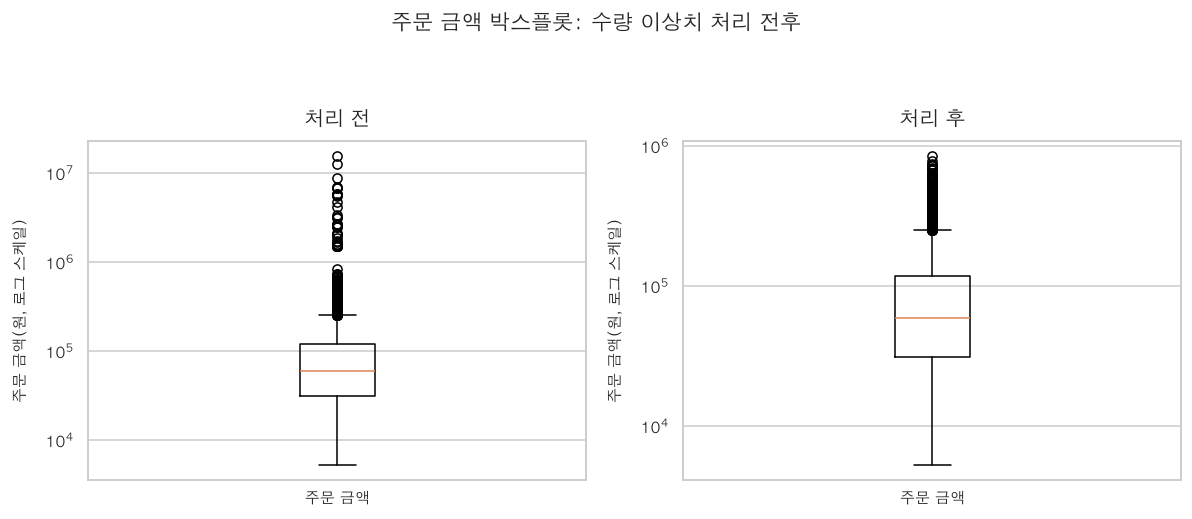

In [22]:
amount_before = analyzer.df["amount"].copy()
amount_outliers = analyzer.detect_outliers("amount", threshold=1.5)
amount_bounds = dict(analyzer.outlier_bounds["amount"])
quantity_outliers = analyzer.detect_outliers("quantity", threshold=1.5)
quantity_bounds = dict(analyzer.outlier_bounds["quantity"])
print("amount_iqr", len(amount_outliers), {key: round(value, 2) for key, value in amount_bounds.items()})
print("quantity_iqr", len(quantity_outliers), {key: round(value, 2) for key, value in quantity_bounds.items()})
print("quantity_max_before", int(analyzer.df["quantity"].max()))

treated = analyzer.treat_outliers("quantity", threshold=1.5, method="clip")
analyzer.recalculate_amount()
amount_after = analyzer.df["amount"].copy()
print("clipped_quantity", treated["n_outliers"], "upper", round(treated["bounds"]["upper"], 2))
print(
    "amount_mean", round(amount_before.mean(), 1), "->", round(amount_after.mean(), 1),
    "median", round(amount_before.median(), 1), "->", round(amount_after.median(), 1),
    "std", round(amount_before.std(), 1), "->", round(amount_after.std(), 1),
    "max", round(amount_before.max(), 1), "->", round(amount_after.max(), 1),
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
axes[0].boxplot(amount_before.to_numpy(), orientation="vertical", showfliers=True)
axes[0].set_yscale("log")
axes[0].set_xticks([])
style_ax(axes[0], "처리 전", "주문 금액", "주문 금액(원, 로그 스케일)")
axes[1].boxplot(amount_after.to_numpy(), orientation="vertical", showfliers=True)
axes[1].set_yscale("log")
axes[1].set_xticks([])
style_ax(axes[1], "처리 후", "주문 금액", "주문 금액(원, 로그 스케일)")
fig.suptitle("주문 금액 박스플롯: 수량 이상치 처리 전후", fontproperties=KFONT, fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.92))
plt.show()


### 이상치 해석

수량 48건을 3.5로 캡핑하면 주문 금액 평균은 131,485원에서 94,693원으로 줄고, 표준편차는 481,700원에서 100,305원으로 줄어 최댓값은 15,518,100원에서 846,900원이 된다. 중앙값은 60,000원에서 59,600원으로 거의 그대로다.

시사점: 평균과 표준편차를 키우던 것은 수량 48건의 폭주이고, 전형적인 주문 금액은 처리 전후 모두 약 6만 원이다. 이후 통계와 RFM은 이 처리 후 금액을 쓴다.


## 6. 그룹별 결측치 대치

`handle_missing_values(strategy="group_mean", group_col="category", target_col="rating")`는 카테고리 평균으로 `rating`을 채우고, 어떤 카테고리가 전부 비어 있으면 전체 평균으로 한 번 더 채운다.


In [25]:
imputed = analyzer.handle_missing_values(
    strategy="group_mean",
    group_col="category",
    target_col="rating",
)
print(imputed)
analyzer.df.groupby("category")["rating"].agg(["mean", "median", "count"]).sort_values("mean")


{'column': 'rating', 'strategy': 'group_mean', 'group_col': 'category', 'missing_before': 471, 'missing_after': 0}


,mean,median,count
category,,,
Food,3.4000,3.4000,521
Fashion,3.9034,3.9000,756
Home,4.0237,4.0237,552
Sports,4.0898,4.0898,645
Electronics,4.2072,4.2072,940
Beauty,4.4908,4.4908,585


### 대치 해석

카테고리 평균 대치로 평점 결측은 471건에서 0건이 된다. Food 평균은 3.40, Beauty 평균은 4.49로 대치 전과 같다. Beauty 중앙값은 관측값 기준 4.5에서, 평균과 같은 4.49로 이동한다. 채워 넣은 값이 모두 그 카테고리 평균이기 때문이다.

시사점: 이 대치는 카테고리 간 평점 차이(Beauty 4.49, Food 3.40)를 유지하므로 이후 카테고리 비교에 쓸 수 있고, 중앙값을 상품 품질의 순위로 쓰면 대치 비율이 높은 카테고리에서 평균 쪽으로 붙는다.


## 7. 요약 통계

처리와 대치가 끝난 수치 변수에 대해 평균, 중앙값, 표준편차, 사분위수를 계산한다.


In [28]:
summary_columns = [
    "amount",
    "unit_price",
    "quantity",
    "rating",
    "image_mean",
    "name_length",
    "name_word_count",
]
analyzer.summary_statistics(summary_columns)


,column,count,mean,median,std,min,q1,q2,q3,max
0,amount,3999,"94,693.2983","59,600.0000","100,304.7522","5,300.0000","31,000.0000","59,600.0000","118,550.0000","846,900.0000"
1,unit_price,3999,"54,415.7789","38,200.0000","47,237.6729","5,300.0000","21,200.0000","38,200.0000","72,500.0000","297,100.0000"
2,quantity,3999,1.6882,2.0000,0.6970,1.0000,1.0000,2.0000,2.0000,3.5000
3,rating,3999,4.0418,4.0898,0.4457,2.4000,3.8000,4.0898,4.3000,5.0000
4,image_mean,3999,0.6053,0.6005,0.1872,0.3196,0.4705,0.6005,0.7470,0.9474
5,name_length,3999,9.9542,10.0000,2.6341,3.0000,8.0000,10.0000,11.0000,18.0000
6,name_word_count,3999,2.9055,3.0000,0.6620,1.0000,3.0000,3.0000,3.0000,4.0000


### 요약 통계 해석

처리 후 주문 금액은 평균 94,693원, 중앙값 59,600원, 표준편차 100,305원, Q1 31,000원, Q2 59,600원, Q3 118,550원, 최댓값 846,900원이다. 평균은 여전히 중앙값의 1.59배다. 단가는 평균 54,416원, 중앙값 38,200원, 표준편차 47,238원이다. 수량은 평균 1.69, 중앙값 2, 최댓값 3.5다. 평점은 평균 4.04, 중앙값 4.09, 표준편차 0.45, 범위 2.4~5.0이다.

시사점: 금액의 오른쪽 꼬리는 고가 상품 때문에 남아 있으므로 목표 객단가는 평균 94,693원보다 중앙값 59,600원에 가깝게 잡고, 평점은 전체 표준편차 0.45보다 카테고리 평균 차이로 상품을 비교한다.


## 8. 히트맵: 상관행렬

아래 행렬은 피어슨 상관계수다. 금액·단가·수량 쌍과, 이미지 평균·단가 쌍을 같이 읽는다.


,amount,unit_price,quantity,rating,image_mean,name_word_count,name_length
amount,1.0000,0.8510,0.4760,0.0220,-0.1990,0.2100,0.1260
unit_price,0.8510,1.0000,0.0860,0.0230,-0.2280,0.2520,0.1390
quantity,0.4760,0.0860,1.0000,0.0220,-0.0500,0.0120,0.0300
rating,0.0220,0.0230,0.0220,1.0000,-0.0880,0.0510,0.0430
image_mean,-0.1990,-0.2280,-0.0500,-0.0880,1.0000,-0.1020,-0.3780
name_word_count,0.2100,0.2520,0.0120,0.0510,-0.1020,1.0000,0.5750
name_length,0.1260,0.1390,0.0300,0.0430,-0.3780,0.5750,1.0000


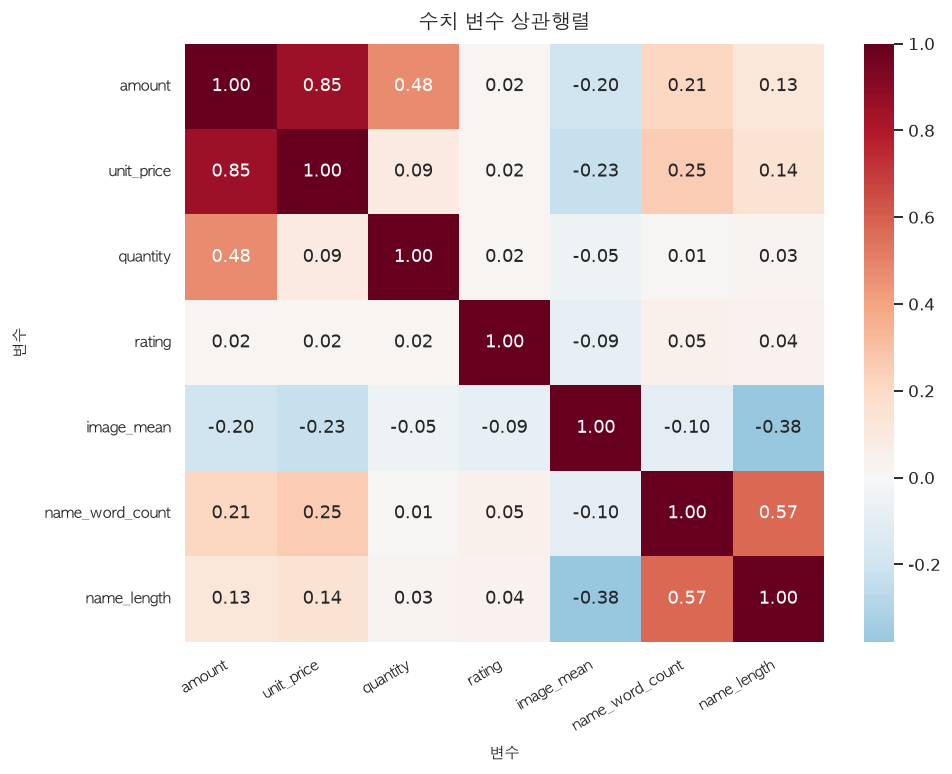

In [31]:
corr_columns = [
    "amount",
    "unit_price",
    "quantity",
    "rating",
    "image_mean",
    "name_word_count",
    "name_length",
]
corr = analyzer.correlation_matrix(corr_columns)
display(corr.round(3))

fig, ax = plt.subplots(figsize=(9.2, 7.2))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
style_ax(ax, "수치 변수 상관행렬", "변수", "변수")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
for label in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
    label.set_fontproperties(KFONT)
fig.tight_layout()
plt.show()


### 상관 해석

단가와 주문 금액의 상관계수는 0.851이고, 수량과 주문 금액은 0.476이다. 평점과 주문 금액은 0.022로 거의 같이 움직이지 않는다. 이미지 평균과 단가의 상관계수는 −0.228이다. Electronics 이미지 평균은 0.348로 가장 어둡고, Fashion 이미지 평균은 0.707인데 Fashion 평균 주문액은 157,807원으로 여섯 카테고리 중 가장 높다. 상품명 길이와 단어 수의 상관계수는 0.575다.

시사점: 이 데이터의 주문 금액 차이는 수량보다 단가와 더 크게 함께 움직이고, 이미지 밝기만으로 가격대를 나누면 밝으면서 평균 주문액이 157,807원인 Fashion을 놓친다.


## 9. 히스토그램: 단가 분포

단가는 이상치 캡핑을 하지 않은 수치 변수다. 평균과 중앙값을 세로선으로 겹친다.


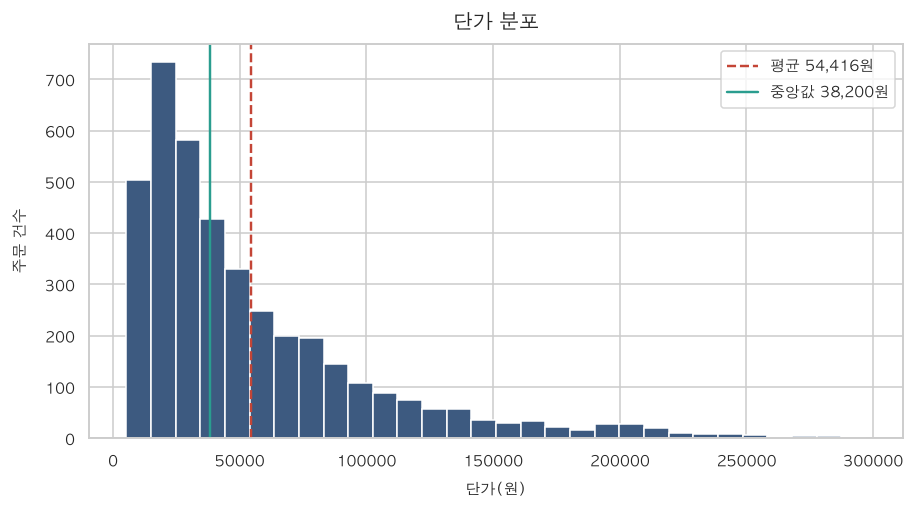

In [34]:
mean_price = float(analyzer.df["unit_price"].mean())
median_price = float(analyzer.df["unit_price"].median())

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.hist(analyzer.df["unit_price"], bins=30, color="#3D5A80", edgecolor="white")
ax.axvline(mean_price, color="#C44536", linestyle="--", linewidth=1.6, label=f"평균 {mean_price:,.0f}원")
ax.axvline(median_price, color="#2A9D8F", linestyle="-", linewidth=1.6, label=f"중앙값 {median_price:,.0f}원")
style_ax(ax, "단가 분포", "단가(원)", "주문 건수")
ax.legend(prop=KFONT)
fig.tight_layout()
plt.show()


### 히스토그램 해석

단가 평균 54,416원은 중앙값 38,200원보다 오른쪽에 있다. 최댓값은 297,100원이고, 주문의 절반은 38,200원 이하다.

시사점: 단가 할인을 평균 단가에 맞추면 다수 주문(중앙값 38,200원 이하)보다 높은 가격대를 기준으로 삼게 된다.


## 10. 산점도: 단가와 주문 금액

처리 후 주문 금액과 단가의 관계를 카테고리 색으로 본다.


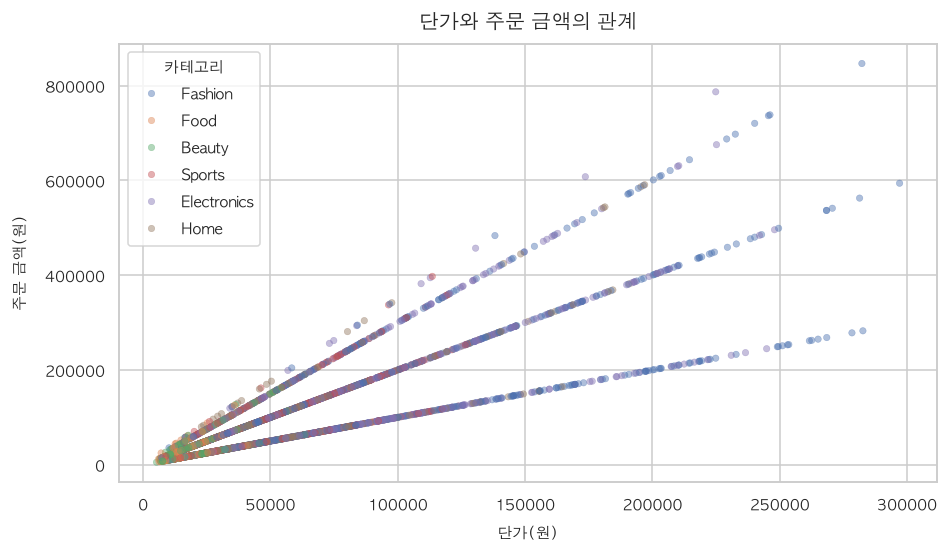

In [37]:
fig, ax = plt.subplots(figsize=(8.8, 5.2))
sns.scatterplot(
    data=analyzer.df,
    x="unit_price",
    y="amount",
    hue="category",
    ax=ax,
    alpha=0.45,
    s=18,
    edgecolor=None,
)
style_ax(ax, "단가와 주문 금액의 관계", "단가(원)", "주문 금액(원)")
style_legend(ax, "카테고리")
fig.tight_layout()
plt.show()


### 산점도 해석

점이 오른쪽 위로 퍼지고 상관계수는 0.851이다. 같은 단가에서도 수량이 1~3.5라 주문 금액이 세로로 조금 갈라진다. Fashion과 Electronics 점이 단가·금액이 높은 쪽에 더 많이 놓인다.

시사점: 주문 금액을 가르는 축은 수량 증정보다 어떤 단가의 상품이 팔리느냐에 가깝다.


## 11. 막대그래프: 카테고리별 주문 건수

범주 빈도는 주문 건수이고, 매출 비중은 표로 같이 본다. 건수는 이상치 처리와 무관하다.


,orders,revenue,avg_amount,avg_rating,revenue_share
category,,,,,
Fashion,756,"119,302,250.0000","157,807.2090",3.9034,0.3150
Electronics,940,"114,208,950.0000","121,498.8830",4.2072,0.3016
Sports,645,"53,614,150.0000","83,122.7132",4.0898,0.1416
Home,552,"53,337,550.0000","96,625.9964",4.0237,0.1409
Beauty,585,"22,268,350.0000","38,065.5556",4.4908,0.0588
Food,521,"15,947,250.0000","30,608.9251",3.4000,0.0421


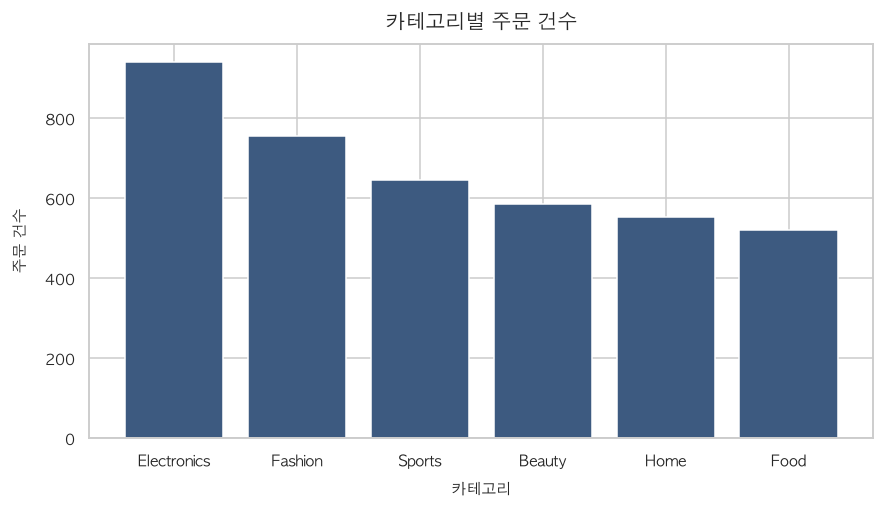

In [40]:
category_summary = analyzer.df.groupby("category").agg(
    orders=("order_id", "size"),
    revenue=("amount", "sum"),
    avg_amount=("amount", "mean"),
    avg_rating=("rating", "mean"),
)
category_summary = category_summary.sort_values("revenue", ascending=False)
category_summary["revenue_share"] = category_summary["revenue"] / category_summary["revenue"].sum()
display(category_summary)

order_counts = category_summary.sort_values("orders", ascending=False)
fig, ax = plt.subplots(figsize=(8.2, 4.8))
ax.bar(order_counts.index.astype(str), order_counts["orders"], color="#3D5A80")
style_ax(ax, "카테고리별 주문 건수", "카테고리", "주문 건수")
fig.tight_layout()
plt.show()


### 카테고리 해석

주문 건수는 Electronics 940, Fashion 756, Sports 645, Beauty 585, Home 552, Food 521건이다. 매출은 Fashion 119,302,250원(31.5%), Electronics 114,208,950원(30.2%)이라 둘을 합하면 61.7%다. 평균 주문액은 Fashion 157,807원, Food 30,609원이다. 평점 평균은 Beauty 4.49, Food 3.40이다.

시사점: 건수가 가장 많은 Electronics와 평균 주문액이 가장 높은 Fashion이 매출의 축이고, Food는 건수 대비 매출과 평점이 모두 낮다.


## 12. 라인차트: 월별 매출

처리 후 주문 금액을 월 시작일 기준으로 합친다.


recent_3m_revenue 91700250.0
peak 2024-12-01 39896800.0 421


,revenue,orders
order_date,,
2024-03-01,"750,100.0000",9
2024-04-01,"2,317,200.0000",23
2024-05-01,"6,485,500.0000",52
2024-06-01,"9,649,750.0000",107
2024-07-01,"15,278,150.0000",170
2024-08-01,"18,828,850.0000",219
2024-09-01,"21,918,800.0000",251
2024-10-01,"28,158,050.0000",311
2024-11-01,"35,925,400.0000",342


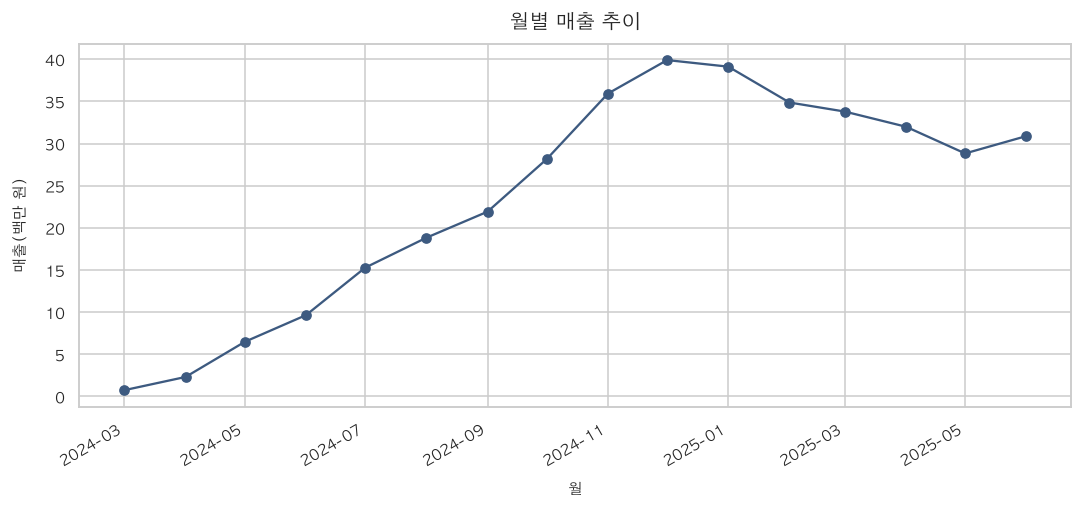

In [43]:
monthly = (
    analyzer.df.set_index("order_date")["amount"]
    .resample("MS")
    .agg(revenue="sum", orders="count")
)
display(monthly)

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(monthly.index, monthly["revenue"], marker="o", color="#3D5A80")
style_ax(ax, "월별 매출 추이", "월", "매출(백만 원)")
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _pos: f"{value/1e6:.0f}"))
fig.autofmt_xdate()
fig.tight_layout()
plt.show()
print("recent_3m_revenue", round(float(monthly["revenue"].iloc[-3:].sum()), 1))
print("peak", monthly["revenue"].idxmax().date(), round(float(monthly["revenue"].max()), 1), int(monthly.loc[monthly["revenue"].idxmax(), "orders"]))


### 월별 추이 해석

2024년 3월 매출은 750,100원(9건)이고 2024년 12월은 39,896,800원(421건)이다. 2025년 5월은 28,825,150원(298건), 2025년 6월은 30,881,250원(325건)이다. 12월 대비 5월 매출은 27.8% 낮다. 최근 3개월(2025-04~06) 매출 합은 91,700,250원이다.

시사점: 구매 이력을 마지막 구매일에서 과거로 쌓은 데이터라 2024년 봄의 낮은 매출을 성장률로 쓰기보다, 주문이 충분히 쌓인 최근 3개월 매출 91,700,250원을 운영 규모로 본다.


## 13. RFM 고객 세분화

`calculate_rfm()`은 `customer_id`, `order_date`, `amount`로 고객별 Recency(기준일 − 마지막 구매일), Frequency(주문 수), Monetary(금액 합)를 만든다. 기준일을 생략하면 최종 거래일 2025-06-30이 된다. 점수는 동점을 순위 기준으로 나눈 5분위다. Recency는 경과일수가 작을수록 높은 점수다.

세그먼트 규칙은 앞에서부터 적용한다. VIP는 R·F·M이 모두 4 이상, Loyal은 모두 3 이상, New는 R이 4 이상이고 F가 2 이하, At Risk는 R이 2 이하이고 F·M이 3 이상, Churned는 R·F가 모두 2 이하, 나머지는 Regular다.


In [46]:
rfm = analyzer.calculate_rfm(
    customer_col="customer_id",
    date_col="order_date",
    amount_col="amount",
    reference_date=None,
)
print("reference_date", analyzer.reference_date.date(), "customers", len(rfm))
display(rfm[["recency", "frequency", "monetary", "R_score", "F_score", "M_score", "segment"]].head())
display(rfm[["recency", "frequency", "monetary"]].describe())

profile = analyzer.segment_profile()
view = profile.copy()
view["customer_share_pct"] = view["customer_share"] * 100
view["revenue_share_pct"] = view["revenue_share"] * 100
display(
    view[
        [
            "customers",
            "customer_share_pct",
            "avg_recency",
            "median_recency",
            "avg_frequency",
            "avg_monetary",
            "median_monetary",
            "total_monetary",
            "revenue_share_pct",
        ]
    ].round(2)
)

vip_orders = analyzer.df.merge(analyzer.rfm[["segment"]], left_on="customer_id", right_index=True)
vip_revenue = (
    vip_orders.loc[vip_orders["segment"] == "VIP"]
    .groupby("category")["amount"]
    .sum()
    .sort_values(ascending=False)
)
vip_share = vip_revenue / vip_revenue.sum()
print("vip_revenue_total", round(float(vip_revenue.sum()), 1))
print(vip_share.round(3))
print(
    "vip_fashion_electronics_share",
    round(float(vip_share.loc[["Fashion", "Electronics"]].sum()), 4),
)


reference_date 2025-06-30 customers 640
vip_revenue_total 214018400.0
category
Electronics   0.3390
Fashion       0.3390
Sports        0.1360
Home          0.1150
Beauty        0.0410
Food          0.0300
Name: amount, dtype: float64
vip_fashion_electronics_share 0.6786


,recency,frequency,monetary,R_score,F_score,M_score,segment
customer_id,,,,,,,
C0001,134,4,"195,700.0000",2,3,2,Regular
C0002,314,3,"160,000.0000",1,2,2,Churned
C0003,188,2,"172,900.0000",2,2,2,Churned
C0004,46,11,"659,800.0000",3,5,4,Loyal
C0005,19,8,"443,400.0000",4,4,3,Loyal


,recency,frequency,monetary
count,640.0000,640.0000,640.0000
mean,98.0141,6.2484,"591,685.1562"
std,111.1652,5.2511,"767,768.7135"
min,0.0000,1.0000,"7,700.0000"
25%,13.0000,1.0000,"82,100.0000"
50%,40.0000,5.0000,"320,150.0000"
75%,149.0000,9.2500,"749,200.0000"
max,380.0000,22.0000,"4,256,550.0000"


,customers,customer_share_pct,avg_recency,median_recency,avg_frequency,avg_monetary,median_monetary,total_monetary,revenue_share_pct
segment,,,,,,,,,
VIP,113,17.6600,10.1200,11.0000,14.4500,"1,893,968.1400","1,796,500.0000","214,018,400.0000",56.5200
Loyal,153,23.9100,38.9000,37.0000,8.1300,"548,773.8600","505,500.0000","83,962,400.0000",22.1700
New,110,17.1900,9.8800,9.0000,1.0000,"53,682.2700","39,250.0000","5,905,050.0000",1.5600
At Risk,95,14.8400,124.2100,121.0000,7.0300,"589,676.8400","548,000.0000","56,019,300.0000",14.7900
Churned,141,22.0300,272.1700,275.0000,1.7900,"107,548.5800","91,100.0000","15,164,350.0000",4.0000
Regular,28,4.3800,156.1400,117.0000,3.2900,"128,892.8600","145,500.0000","3,609,000.0000",0.9500


### 세그먼트 해석

고객 640명, 처리 후 총매출 378,678,500원, 기준일 2025-06-30이다.

- VIP 113명(17.7%)의 평균 최근성은 10.1일, 중앙값은 11일, 평균 구매는 14.45회, 평균 누적 구매액은 1,893,968원이다. 매출 214,018,400원으로 비중이 56.5%다.
- Loyal 153명(23.9%)은 평균 최근성 38.9일, 평균 8.13회, 평균 누적 548,774원이고 매출 비중 22.2%가 고객 비중과 비슷하다.
- New 110명(17.2%)은 구매 횟수가 모두 1회이고 평균 누적 53,682원, 최근성 중앙값 9일, 매출 비중 1.6%다.
- At Risk 95명(14.8%)은 평균 누적 589,677원으로 Loyal과 가깝고, 최근성 중앙값은 121일, 매출 비중은 14.8%다.
- Churned 141명(22.0%)은 최근성 중앙값 275일, 평균 1.79회, 매출 비중 4.0%다.
- Regular 28명(4.4%)은 위 규칙 밖의 중간 집단이고 매출 비중은 1.0%다.

시사점: 고객 수의 22.0%인 Churned보다, 매출의 14.8%를 아직 갖고 있는 At Risk와 매출의 56.5%를 만드는 VIP가 관리 우선순위다.


## 14. 막대그래프: RFM 세그먼트별 고객 수


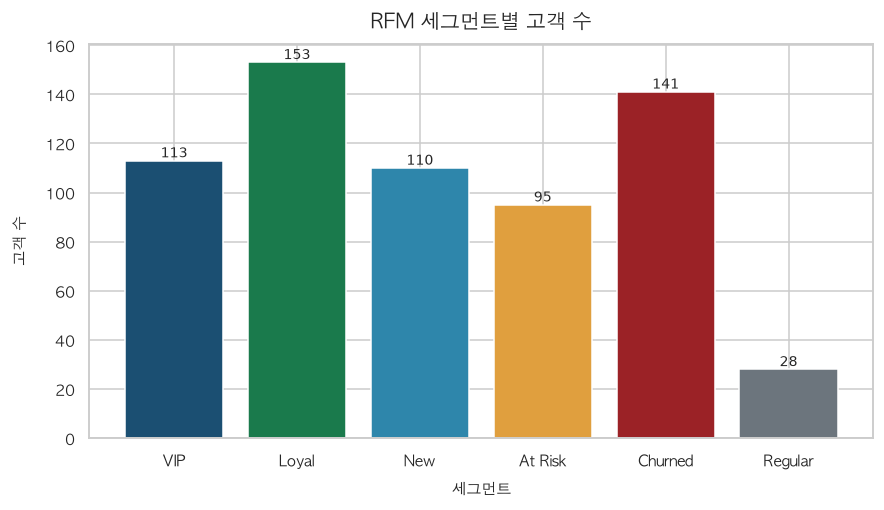

In [49]:
segment_counts = (
    analyzer.rfm["segment"]
    .value_counts()
    .reindex([name for name in SEGMENT_ORDER if name in set(analyzer.rfm["segment"])])
)
segment_colors = {
    "VIP": "#1B4F72",
    "Loyal": "#1A7A4C",
    "New": "#2E86AB",
    "At Risk": "#E09F3E",
    "Churned": "#9B2226",
    "Regular": "#6C757D",
}

fig, ax = plt.subplots(figsize=(8.2, 4.8))
bars = ax.bar(
    segment_counts.index.astype(str),
    segment_counts.to_numpy(),
    color=[segment_colors[name] for name in segment_counts.index],
)
style_ax(ax, "RFM 세그먼트별 고객 수", "세그먼트", "고객 수")
for bar, value in zip(bars, segment_counts.to_numpy()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value)}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
fig.tight_layout()
plt.show()


### 세그먼트 막대 해석

고객 수는 Loyal 153, Churned 141, VIP 113, New 110, At Risk 95, Regular 28명이다. 여섯 집단 모두 1명 이상이라 규칙은 한쪽으로 쏠려 비지 않았다.

시사점: 인원만 보면 Churned가 VIP보다 많지만, 매출 비중은 VIP 56.5%, Churned 4.0%라서 막대 높이를 예산 배분의 순서로 쓰면 안 된다.


## 15. 비즈니스 인사이트

수치는 위 RFM 표와 카테고리 표를 기준으로 한다. 실행안과 검증에 필요한 추가 데이터는 `README.md`와 같다.

1. VIP 113명(17.7%)이 매출의 56.5%(214,018,400원)를 만든다. 평균 구매 14.45회, 마지막 구매 중앙값 11일이다. VIP 매출의 67.9%는 Electronics와 Fashion이다. 이 113명에게 두 카테고리 신상품 선공개와 무료 반품이 포함된 멤버십을 제안해 최근 구매 주기를 유지한다. 멤버십 효과는 혜택 사용 로그가 있어야 확인할 수 있다.

2. At Risk 95명의 평균 누적 구매액 589,677원은 Loyal 548,774원과 가깝고, 마지막 구매 중앙값은 121일이다. 매출 기여는 14.8%다. Churned 141명은 고객의 22.0%이지만 매출 기여는 4.0%이고 최근성 중앙값은 275일이다. At Risk에게 마지막 카테고리의 7일 재구매 쿠폰을 먼저 보낸다. 121일이 가격 불만인지는 대조군 실험이 있어야 가릴 수 있다.

3. New 110명은 구매가 모두 1회, 평균 53,682원, 최근성 중앙값 9일, 매출 비중 1.6%다. 첫 구매 후 14일 안에 쓰는 2차 구매 쿠폰을 첫 카테고리 연관 상품에 건다. 1회 구매가 의도된 단건인지는 가입일과 유입 경로가 있어야 알 수 있다.

4. Fashion과 Electronics 매출 합은 전체의 61.7%다. Food 평균 주문액은 30,609원, 평점 평균은 3.40, 결측률은 22.8%다. 진열 우선순위는 Fashion·Electronics에 두고, Food에는 리뷰 요청과 품질 점검을 둔다. 결측 원인은 리뷰 노출 로그가 있어야 한다.


In [52]:
assert len(analyzer.df) >= 1000
assert analyzer.df.shape[1] >= 8
assert {"customer_id", "order_date", "amount", "product_name", "image_mean", "name_word_count"} <= set(analyzer.df.columns)
assert int(analyzer.df["rating"].isna().sum()) == 0
assert analyzer.reference_date == pd.Timestamp("2025-06-30")
assert analyzer.rfm["segment"].nunique() >= 4
assert set(analyzer.rfm["segment"]) >= {"VIP", "Loyal", "New", "At Risk", "Churned"}
print("checks_ok", analyzer.df.shape, analyzer.rfm["segment"].nunique())


checks_ok (3999, 17) 6
